# Optimizer Test

## 1. data 업로드

In [1]:
from tensorflow.keras.datasets import fashion_mnist

(x,y), (x_test, y_test) = fashion_mnist.load_data()

## 2. data 전처리

In [2]:
from tensorflow.keras.utils import to_categorical

x = x.astype('float32')
x_test = x_test.astype('float32')

x = x.reshape(60000,-1)
x_test = x_test.reshape(10000,-1)

x = x/255.
x_test = x/ 255.

y = to_categorical(y, 10)
y_test = to_categorical(y_test, 10)

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 1/6, random_state=3, shuffle = True, stratify=y)

## 3. optimizer list 만들기

In [5]:
!pip install keras-rectified-adam

  Using cached keras-rectified-adam-0.17.0.tar.gz (11 kB)
  Using cached Keras-2.4.3-py2.py3-none-any.whl (36 kB)
  Created wheel for keras-rectified-adam: filename=keras_rectified_adam-0.17.0-py3-none-any.whl size=14787 sha256=b6093f2001b692bb53f27ca6d86acc8204183ef636756be97fc97d9c8a66de6c
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\52\b5\63\66248e565fe06bb8e7131d88be76e0e2f9d866af835eea481a
Successfully built keras-rectified-adam


In [2]:
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from keras_radam.training import RAdamOptimizer

In [7]:
sgd = SGD(learning_rate=0.001, momentum=0.0, nesterov=False)
momentum = SGD(learning_rate=0.001, momentum=0.9, nesterov=False)
nag = SGD(learning_rate=0.001, momentum=0.9, nesterov=True)
adagrad = Adagrad(learning_rate=0.001)
rmsprop = RMSprop(learning_rate=0.001, rho=0.9)
adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999)
radam = RAdamOptimizer(learning_rate=0.001,beta1=0.9,beta2=0.999)

In [8]:
optimizer_dict = {sgd:'sgd', momentum:'momentum', nag:'nag', adagrad:'adagrad', rmsprop:'rmsprop', adam:'adam', radam:'radam'}

## 4. 모델 만들기

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
def create_model(optimizer_option):
    model = Sequential()
    model.add(Dense(64, input_shape=(784,), activation = 'relu'))
    model.add(Dense(128, activation = 'relu'))
    model.add(Dense(256, activation = 'relu'))
    model.add(Dense(10, activation = 'softmax'))
    
    model.compile(optimizer = optimizer_option , loss = 'categorical_crossentropy', metrics = ['accuracy'])
    return model

## 5. train

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline

!!!!!!!!!!
sgd
!!!!!!!!!!
Epoch 1/20
98/98 [==============================] - 3s 23ms/step - loss: 2.2791 - accuracy: 0.1253 - val_loss: 2.2437 - val_accuracy: 0.1371
Epoch 2/20
98/98 [==============================] - 1s 7ms/step - loss: 2.2321 - accuracy: 0.1422 - val_loss: 2.1990 - val_accuracy: 0.1941
Epoch 3/20
98/98 [==============================] - 1s 7ms/step - loss: 2.1883 - accuracy: 0.2014 - val_loss: 2.1559 - val_accuracy: 0.2445
Epoch 4/20
98/98 [==============================] - 1s 7ms/step - loss: 2.1453 - accuracy: 0.2464 - val_loss: 2.1118 - val_accuracy: 0.2832
Epoch 5/20
98/98 [==============================] - 1s 7ms/step - loss: 2.1007 - accuracy: 0.2957 - val_loss: 2.0647 - val_accuracy: 0.3475
Epoch 6/20
98/98 [==============================] - 1s 8ms/step - loss: 2.0529 - accuracy: 0.3625 - val_loss: 2.0137 - val_accuracy: 0.4154
Epoch 7/20
98/98 [==============================] - 1s 8ms/step - loss: 2.0010 - accuracy: 0.4377 - val_loss: 1.9584 - val_accuracy: 

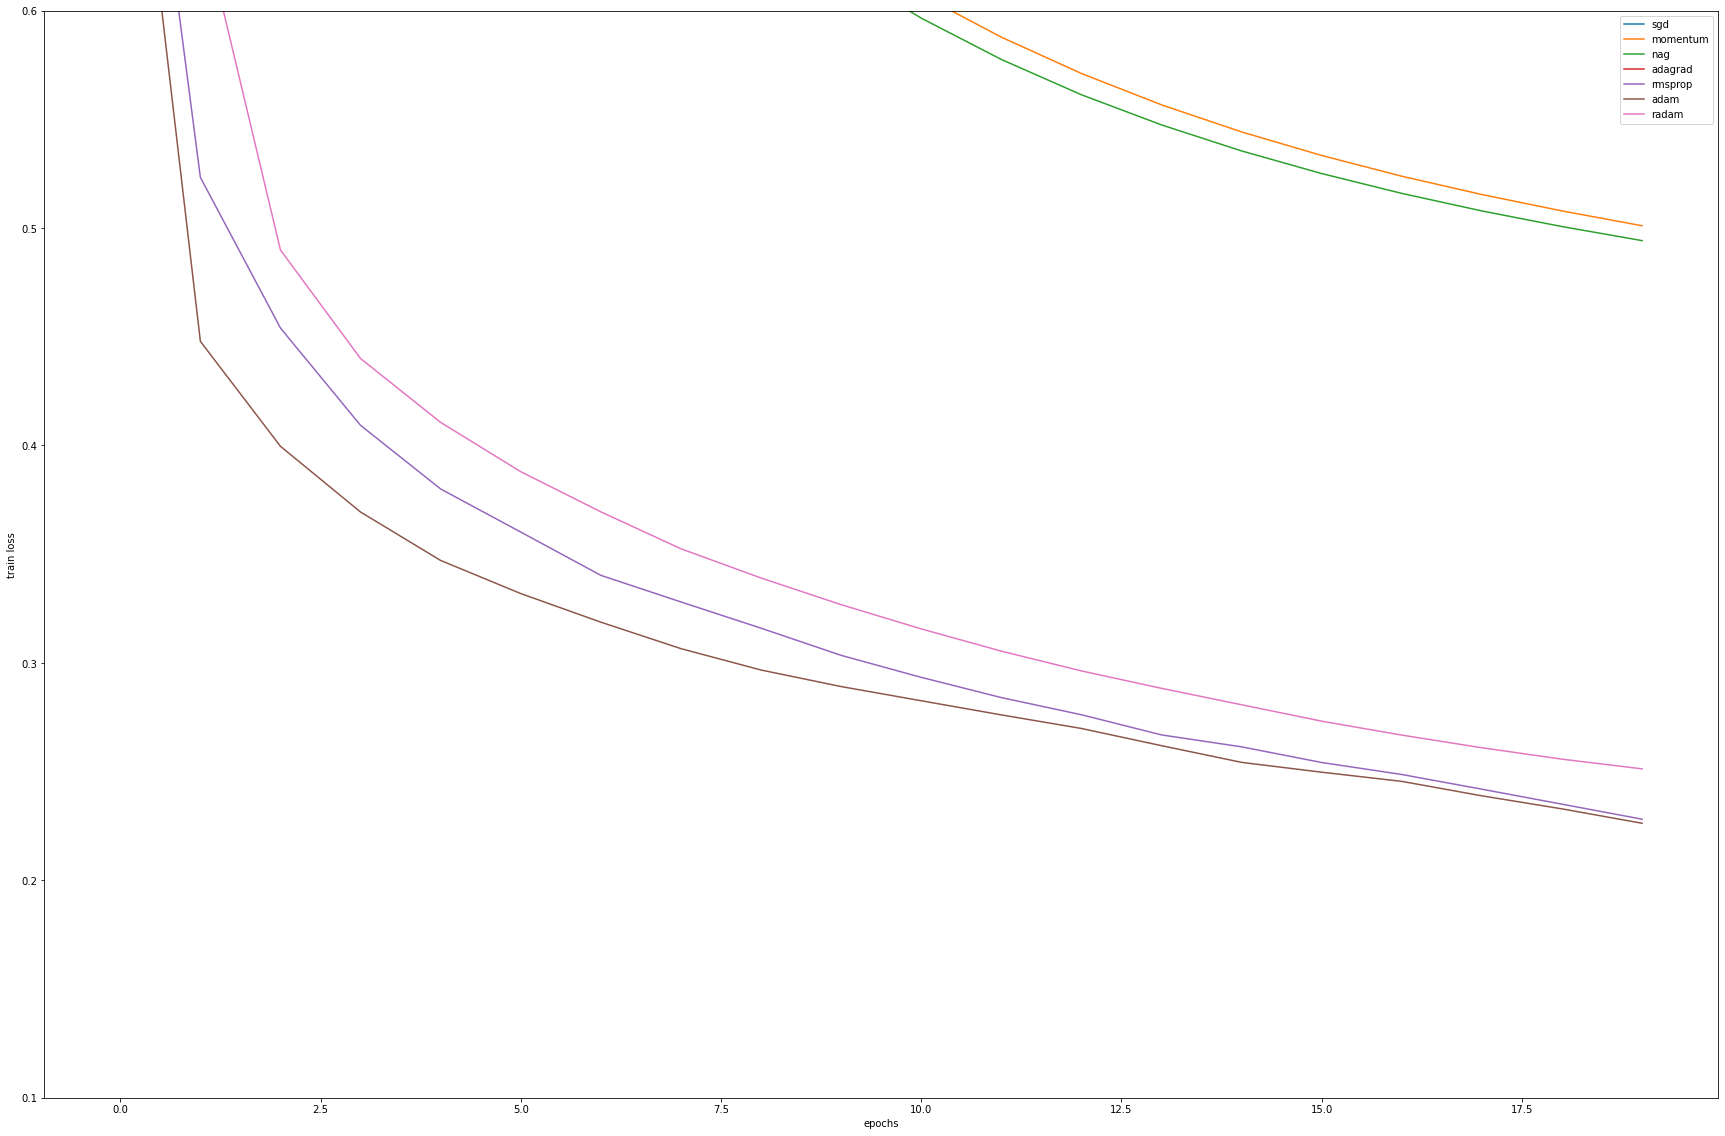

In [12]:
plt.figure(figsize = (30, 20))
for optimizer in optimizer_dict:
    model = create_model(optimizer)
    print('!'*10)
    print(optimizer_dict[optimizer])
    print('!'*10)
    history = model.fit(x, y, epochs=20, batch_size = 512, validation_split=1/6, verbose=1, shuffle=False)
    df = pd.DataFrame(history.history)
    plt.plot(history.epoch, df['loss'], label = optimizer_dict[optimizer])
    
plt.xlabel('epochs')
plt.ylabel('train loss')
plt.ylim([0.1,0.6])
plt.legend()
plt.show()